In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
EPS = 1e-4  # требуемая точность (для 2ух заданий одинаковая)

In [3]:
# Метод простых итераций

# Матрица коэффициентов A и вектор правой части b
A = np.array([
    [0.14, -0.31, -0.17,  0.21],
    [0.22,  0.32,  0.00,  0.19],
    [0.32, -0.15,  0.05, -0.17],
    [0.11,  0.25, -0.13, -0.34],
], dtype=float)

b = np.array([1.73, -0.61, 0.88, -0.96], dtype=float)

# Здесь система Ax = b преобразуется через нормальные уравнения
# После этого используем итерационную схему
lam = 5.0
B = np.eye(4) - lam * (A.T @ A)
c = lam * (A.T @ b)

print("Матрица B:")
print(B)
print("\nВектор c:")
print(c)

# Норма матрицы B нужна для проверки достаточного условия сходимости
print("\nНорма ||B||1 =", np.linalg.norm(B, 1))

Матрица B:
[[ 8.75000000e-02 -3.25000000e-02  1.10500000e-01  1.03000000e-01]
 [-3.25000000e-02 -4.17500000e-01 -6.35000000e-02  3.19000000e-01]
 [ 1.10500000e-01 -6.35000000e-02  7.58500000e-01 -7.54951657e-18]
 [ 1.03000000e-01  3.19000000e-01 -7.54951657e-18 -1.23500000e-01]]

Вектор c:
[ 1.42   -5.5175 -0.6265  2.121 ]

Норма ||B||1 = 0.9325


In [4]:
# Начальное приближение берём нулевым
x = np.zeros(4)
k = 0

while True:
    # Шаг итерационного процесса
    x_new = B @ x + c
    k += 1

    # Достигнута ли заданная точность
    if np.max(np.abs(x_new - x)) < EPS:
        x = x_new
        break

    x = x_new

print("Решение первой системы:")
for i, value in enumerate(x, start=1):
    print(f"x{i} = {value:.6f}")
print("Количество итераций:", k)

Решение первой системы:
x1 = 1.696587
x2 = -3.667585
x3 = -0.853250
x4 = 1.002030
Количество итераций: 28


In [5]:
# Метод Ньютона

# Функция F(x, y)
def F(x, y):
    return np.array([
        math.sin(x + 0.5) - y - 1,
        x + math.cos(y - 2) - 2
    ], dtype=float)

# Матрица Якоби для метода Ньютона
def J(x, y):
    return np.array([
        [math.cos(x + 0.5), -1],
        [1, -math.sin(y - 2)]
    ], dtype=float)

In [6]:
xy = np.array([2.9814, -1.33], dtype=float)
k = 0

while True:
    # Решаем линейную систему на текущем шаге
    delta = np.linalg.solve(J(*xy), -F(*xy))

    # Получаем новое приближение
    xy_new = xy + delta
    k += 1

    # Останавливаемся, когда поправка стала достаточно маленькой
    if np.max(np.abs(delta)) < EPS:
        xy = xy_new
        break

    xy = xy_new

print("Решение второй системы:")
print(f"x = {xy[0]:.6f}")
print(f"y = {xy[1]:.6f}")
print("Количество итераций Ньютона:", k)

Решение второй системы:
x = 2.981637
y = -1.333529
Количество итераций Ньютона: 2


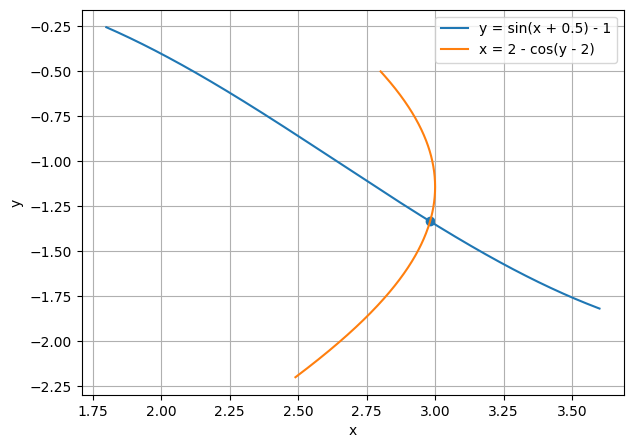

In [7]:
# Выражаем уравнения для построения графика
xx = np.linspace(1.8, 3.6, 600)
y1 = np.sin(xx + 0.5) - 1
yy = np.linspace(-2.2, -0.5, 600)
x2 = 2 - np.cos(yy - 2)

# График
plt.figure(figsize=(7, 5))
plt.plot(xx, y1, label="y = sin(x + 0.5) - 1")
plt.plot(x2, yy, label="x = 2 - cos(y - 2)")
plt.scatter([xy[0]], [xy[1]])
plt.grid(True)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()